In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import requests
!pip install ydata-profiling
from ydata_profiling import ProfileReport

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.8/400.8 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 19.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 60.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 36.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 5.3 MB/s eta 0:00:00


/tmp/ipykernel_806/3267559990.py:7: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install fg-data-profiling via `pip install fg-data-profiling` and use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport


In [4]:
df = pd.read_csv("/content/WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
print(df.shape)

print(df.columns)

print(df.info())

print(df.describe())

(7043, 21)
Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non

In [6]:
print(df.isnull().sum())

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [7]:
print(df.duplicated().sum())

0


In [8]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

In [11]:
df["TotalCharges"].fillna(df["TotalCharges"].median(),inplace=True)

/tmp/ipykernel_806/1795292956.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["TotalCharges"].fillna(df["TotalCharges"].median(),inplace=True)


In [12]:
df.drop_duplicates(inplace=True)

In [13]:
df.drop(
    "customerID",
    axis=1,
    inplace=True
)

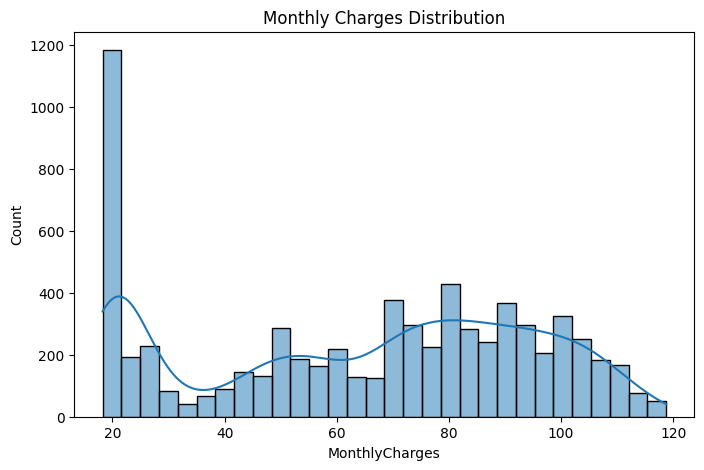

In [14]:
#Univariate Analysis
plt.figure(figsize=(8,5))

sns.histplot(
    df["MonthlyCharges"],
    bins=30,
    kde=True
)

plt.title("Monthly Charges Distribution")

plt.show()

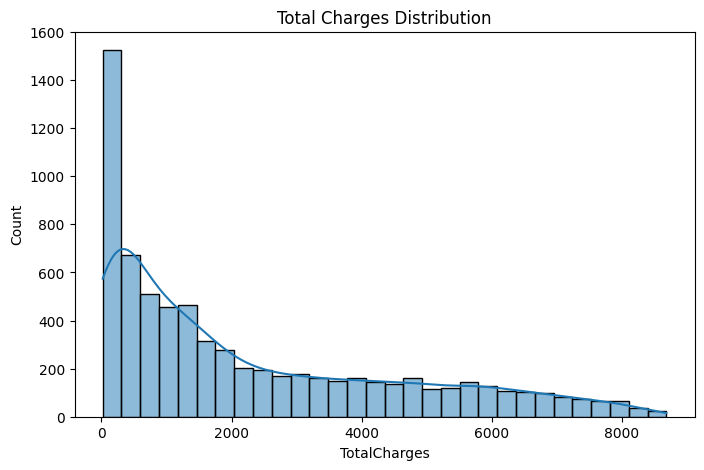

In [15]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["TotalCharges"],
    bins=30,
    kde=True
)

plt.title("Total Charges Distribution")

plt.show()

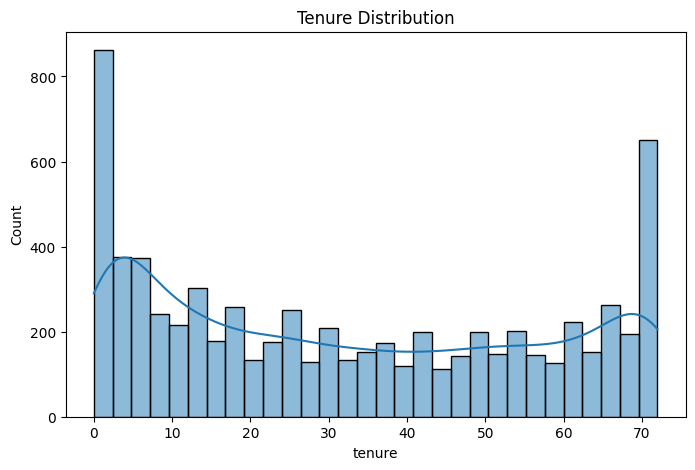

In [16]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["tenure"],
    bins=30,
    kde=True
)

plt.title("Tenure Distribution")

plt.show()

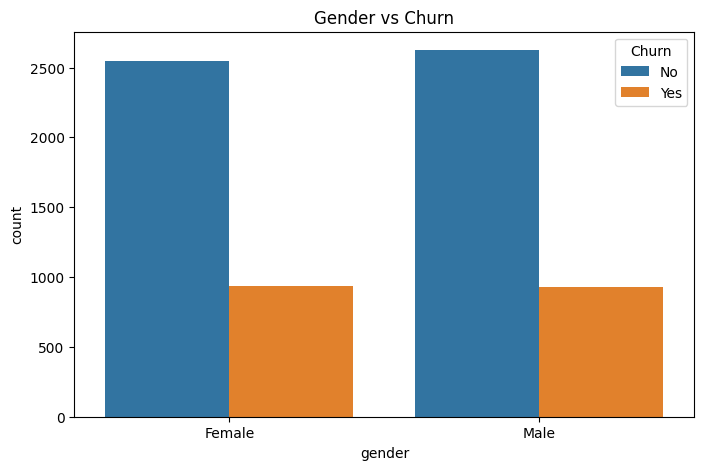

In [17]:
#Bivariate Analysis
plt.figure(figsize=(8,5))

sns.countplot(
    x="gender",
    hue="Churn",
    data=df
)

plt.title("Gender vs Churn")

plt.show()

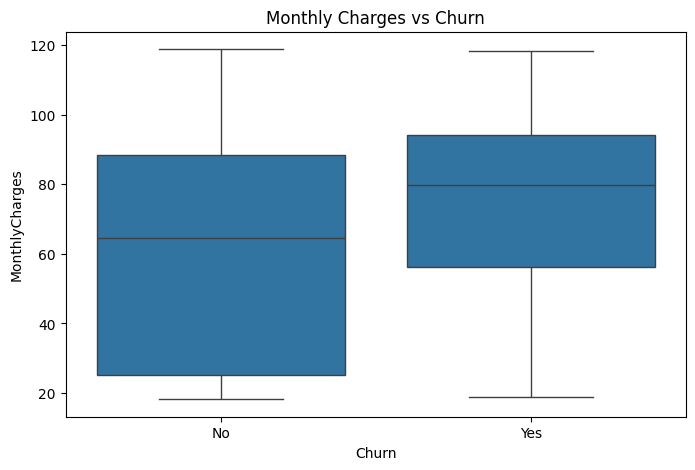

In [18]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Churn",
    y="MonthlyCharges",
    data=df
)

plt.title("Monthly Charges vs Churn")

plt.show()

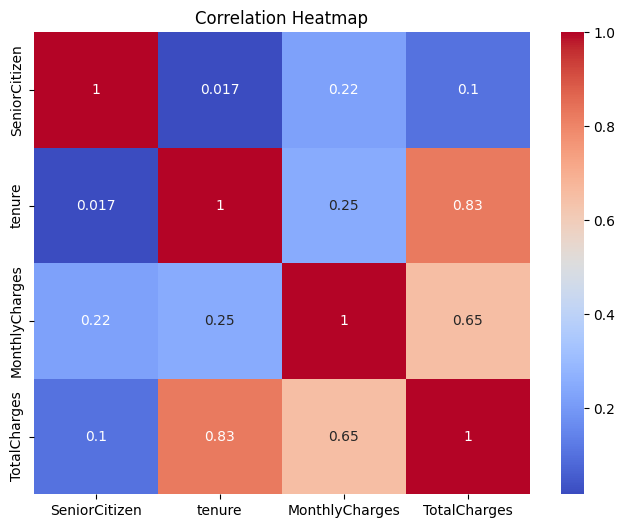

In [19]:
numeric_df = df.select_dtypes(
    include=np.number
)

plt.figure(figsize=(8,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

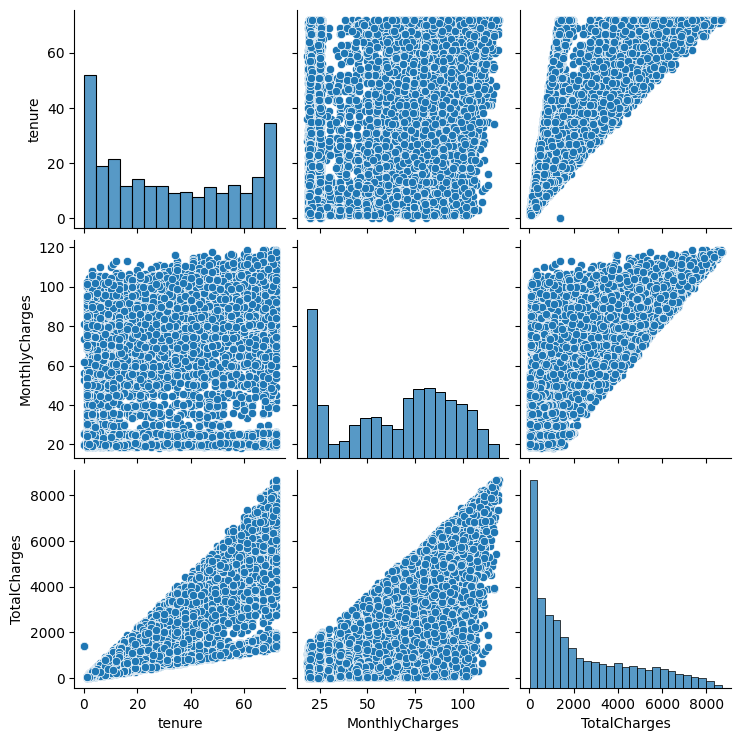

In [20]:
sns.pairplot(
    numeric_df[
        [
            "tenure",
            "MonthlyCharges",
            "TotalCharges"
        ]
    ]
)

plt.show()

In [21]:
sample_json = {
    "Name":["Raj","Amit"],
    "Age":[21,22]
}

json_df = pd.DataFrame(sample_json)

print(json_df)

   Name  Age
0   Raj   21
1  Amit   22


In [23]:
import sqlite3

conn = sqlite3.connect("customer.db")

df.to_sql(
    "customers",
    conn,
    if_exists="replace",
    index=False
)

sql_df = pd.read_sql(
    "SELECT * FROM customers",
    conn
)

sql_df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [25]:
url = "https://randomuser.me/api/?results=5"

response = requests.get(url)

data = response.json()

api_df = pd.json_normalize(
    data["results"]
)

api_df.head()

,gender,email,phone,cell,nat,name.title,name.first,name.last,location.street.number,location.street.name,...,login.sha256,dob.date,dob.age,registered.date,registered.age,id.name,id.value,picture.large,picture.medium,picture.thumbnail
0,male,jean-jacques.roger@example.com,076 670 88 70,075 423 70 66,CH,Monsieur,Jean-Jacques,Roger,9101,Montée Saint-Barthélémy,...,0fd8705bed119732cf72baa45b6eca2cea7b65d64dc9ca...,1970-03-12T16:04:00.109Z,56,2008-11-07T06:40:12.222Z,17,AVS,756.8047.5838.71,https://randomuser.me/api/portraits/men/40.jpg,https://randomuser.me/api/portraits/med/men/40...,https://randomuser.me/api/portraits/thumb/men/...
1,female,arianna.watts@example.com,03-6905-9024,0429-236-967,AU,Mrs,Arianna,Watts,6804,Washington Ave,...,f1221cc728c75848d91efcb753b64e71401fa0901d7cb5...,1971-02-07T06:16:43.340Z,55,2003-08-24T23:25:41.702Z,22,TFN,669773480,https://randomuser.me/api/portraits/women/92.jpg,https://randomuser.me/api/portraits/med/women/...,https://randomuser.me/api/portraits/thumb/wome...
2,male,gerardo.vicente@example.com,942-903-247,653-658-376,ES,Mr,Gerardo,Vicente,7576,Calle de Atocha,...,11aec9625ab8c80e478d1ece94b3772b02ae8d1a3a0f89...,1960-09-11T20:29:25.846Z,65,2007-02-26T03:30:30.994Z,19,DNI,57316285-J,https://randomuser.me/api/portraits/men/70.jpg,https://randomuser.me/api/portraits/med/men/70...,https://randomuser.me/api/portraits/thumb/men/...
3,male,ron.ryan@example.com,0141 916 4563,07677 394951,GB,Mr,Ron,Ryan,3853,Alexander Road,...,f07f31491d392023ed99b085eb4beee60fed93dbc0f7f0...,1991-06-13T06:30:37.986Z,34,2009-12-23T11:34:00.078Z,16,NINO,MP 38 37 51 R,https://randomuser.me/api/portraits/men/3.jpg,https://randomuser.me/api/portraits/med/men/3.jpg,https://randomuser.me/api/portraits/thumb/men/...
4,female,dunja.vucetic@example.com,034-7261-942,061-4576-177,RS,Ms,Dunja,Vučetić,8106,Slavka Vukosavljevića,...,f75c2ddd003c453e36f63add034347d0a517f8c6ef9962...,1981-06-18T11:29:34.044Z,44,2008-10-31T23:12:53.882Z,17,SID,112661614,https://randomuser.me/api/portraits/women/46.jpg,https://randomuser.me/api/portraits/med/women/...,https://randomuser.me/api/portraits/thumb/wome...


In [26]:
profile = ProfileReport(
    df,
    title="Customer Churn Profiling Report"
)

profile.to_file(
    "Customer_Churn_Report.html"
)

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 20/20 [00:02<00:00,  7.31it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

What is Data Analysis?

Data analysis is the process of inspecting, cleaning, transforming, and interpreting data to extract useful information.

What is a Tensor?

A tensor is a multidimensional array used to store and process data in machine learning.

What is Data Cleaning?

Data cleaning is the process of correcting or removing inaccurate, incomplete, or duplicate data.

What is EDA?

Exploratory Data Analysis (EDA) is the process of analyzing datasets using statistics and visualizations to understand patterns and relationships.

What is Data Profiling?

Data profiling is the process of examining data to collect statistics and identify data quality issues.

This flow matches the exact sequence of your practical: Data Acquisition → Data Cleaning → EDA → Data Profiling.